# Supervised machine learning: Introduction and regularization 
## Binary classification with text data

# Imports

In [1]:
## load packages 
import pandas as pd
import re
import numpy as np
import pickle
import matplotlib.pyplot as plt

## nltk imports
from nltk.tokenize import word_tokenize, wordpunct_tokenize
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

## sklearn imports
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

## print mult things
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## random
import random

pd.set_option('display.max_colwidth', None)

In [2]:
## function to process text
def processtext(one_str, stop_list):
    
    ## remove stopwords
    no_stop = [tok for tok in wordpunct_tokenize(one_str)
              if tok not in stop_list]
    
    
    processed_string = " ".join([porter.stem(i.lower()) 
                        for i in no_stop if 
                        i.lower().isalpha() and len(i) >=3])
    return(processed_string)

## function to create dtm
def create_dtm(list_of_strings, metadata):
    vectorizer = CountVectorizer(lowercase = True)
    dtm_sparse = vectorizer.fit_transform(list_of_strings)
    dtm_dense_named = pd.DataFrame(dtm_sparse.todense(), columns=vectorizer.get_feature_names_out())
    dtm_dense_named_withid = pd.concat([metadata.reset_index(), dtm_dense_named], axis = 1)
    return(dtm_dense_named_withid)

# Load data

Load labeled yelp data in `public_data` and run below code

**Note**: make sure to change your path if you need to; if you're having trouble loading the `pkl`, try running on jupyter hub since it may be a python versioning issue

In [3]:
# If you have trouble loading these data (kernel dies due to memory issues), try sampling down to 5000 or 1000 rows
yelp = pd.read_pickle("../public_data/yelp_forML.pkl") #.sample(n=1000)

In [4]:
## preprocess data to create dtm
porter = PorterStemmer()
list_stopwords = stopwords.words("english")

yelp['process_text'] = [processtext(one_review, stop_list = list_stopwords) 
                        for one_review in yelp['raw_text']]

yelp_dtm = create_dtm(yelp['process_text'], yelp[['metadata_label', 'metadata_rowid',
                                                 'process_text', 'raw_text']])

# 1. Split into features, labels, and split into training/hold out

## 1.1 Split into X (features or id metadata) and y (labels)

In [5]:
# X = yelp_dtm[[col for col in yelp_dtm.columns if col not in ['metadata_label',
#                                                             'index']]].copy()
X = yelp_dtm[yelp_dtm.columns[5:]]

y = yelp_dtm[['metadata_label']]

In [6]:
## checking dimensionality
X.shape
y.shape

assert X.shape[0] == y.shape[0]
assert y.shape[1] == 1


(15000, 23438)

(15000, 1)

## 1.2 using automatic function to create train-test split

In [7]:
### using built-in function  
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                   test_size = 0.2,
                                                   random_state = 221)

In [15]:
# This is a great function and use it as much as you can.
X_train
y_train

,aaa,aaaaaa,aaaaaaaaaaaaaaand,aaaaaaaaaaaaahhhhhhhhhhh,aaaaand,aaaaannnd,aaaand,aaaawesomee,aaahhh,aab,...,zoom,zorba,zucchini,zuch,zuchinni,zum,zuma,zumba,zuppa,zwei
497,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
13172,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8200,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6304,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
11359,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3977,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3954,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6324,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12006,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


,metadata_label
497,1
13172,0
8200,0
6304,1
11359,1
...,...
3977,1
3954,1
6324,1
12006,0


## 1.3 using more manual approach to create train-test split

In [9]:
# ### more manually: useful when we want more control
# ### over the ids (eg clustering or time ordering)
# ### or if we want to go back to matrix before preprocessing
# nrows_train = round(X.shape[0]*0.8)
# nrows_test = X.shape[0] - nrows_train
# random.seed(221)
# train_ids = random.sample(list(set(X['metadata_rowid'])), nrows_train)

# def my_split(X, y, 
#              train_ids, 
#              id_col):
    
#     ## get test ids
#     test_ids = set(X[id_col]).difference(train_ids)
    
#     ## split
#     X_train_man = X[X[id_col].isin(train_ids)].copy()
#     X_test_man = X[X[id_col].isin(test_ids)].copy()
#     y_train_man = y[y.index.isin(train_ids)].iloc[:, 0].to_numpy()
#     y_test_man = y[y.index.isin(test_ids)].iloc[:, 0].to_numpy()
    
#     ## return
#     return(X_train_man, X_test_man, y_train_man, y_test_man)

In [21]:
# X_train_man, X_test_man, y_train_man, y_test_man = my_split(X, y,
#                                                             train_ids, 
#                                                             id_col = 'metadata_rowid')


X_train = X_train.loc[:, ~X_train.columns.duplicated(keep="last")]
X_test = X_test.loc[:, ~X_test.columns.duplicated(keep="last")]

# 2. Estimate models with hardcoded parameters: logistic regression with L1 regularization (Lasso)

## 2.1 Estimate model using training data

In [22]:
logit_lasso = LogisticRegression(penalty = "l1",max_iter=100, 
             C = 0.01, solver='liblinear')
logit_lasso.fit(X_train, y_train)

/Users/isaacsaxonov/miniconda3/envs/qsst/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/isaacsaxonov/miniconda3/envs/qsst/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/isaacsaxonov/miniconda3/envs/qsst/lib/python3.12/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties,

## 2.2 Generate predictions in test data

In [23]:
y_pred = logit_lasso.predict(X_test)

y_predprob = logit_lasso.predict_proba(X_test)

In [24]:
## print the results 
y_pred[0:5]
y_predprob[0:5]


array([0, 1, 0, 1, 0])

array([[0.60377503, 0.39622497],
       [0.38783954, 0.61216046],
       [0.56413612, 0.43586388],
       [0.39918793, 0.60081207],
       [0.87859999, 0.12140001]])

## 2.3 Clean up predictions and calculate error metrics

In [25]:
y_test

,metadata_label
7653,0
4969,1
4608,0
13581,1
5982,0
...,...
4772,0
1780,0
6754,1
5798,1


In [26]:
## make into a dataframe
y_pred_df = pd.DataFrame({'y_pred_binary': y_pred,
                         'y_pred_continuous': [one_prob[1] 
                                            for one_prob in y_predprob],
                         'y_true': y_test.metadata_label.values})
y_pred_df.sample(n = 10, random_state = 4484)


,y_pred_binary,y_pred_continuous,y_true
656,0,0.062896,0
825,1,0.770380,1
1641,0,0.381530,0
2249,1,0.508839,1
1080,0,0.492702,1
2490,0,0.318132,0
2857,0,0.328020,1
1160,1,0.786575,1
1061,0,0.453870,0
2255,1,0.708497,1


In [27]:
## precision as tp / tp+fp 
error_cond = [(y_pred_df['y_true'] == 1) & (y_pred_df['y_pred_binary'] == 1),
             (y_pred_df['y_true'] == 1) & (y_pred_df['y_pred_binary'] == 0),
              (y_pred_df['y_true'] == 0) & (y_pred_df['y_pred_binary'] == 0)]

error_codeto = ["TP", "FN", "TN"]

y_pred_df['error_cat'] = np.select(error_cond, error_codeto, default = "FP")
y_error = y_pred_df.error_cat.value_counts().reset_index().copy()
y_error.columns = ['cat', 'n']
y_error

### precision
print("Precision is:-----------")
y_error.loc[y_error.cat == "TP", 'n'].iloc[0]/(y_error.loc[y_error.cat == "TP", 'n'].iloc[0] +
                    y_error.loc[y_error.cat == "FP", 'n'].iloc[0])

### recall
print("Recall is:---------------")
y_error.loc[y_error.cat == "TP", 'n'].iloc[0]/(y_error.loc[y_error.cat == "TP", 'n'].iloc[0] +
                    y_error.loc[y_error.cat == "FN", 'n'].iloc[0])

,cat,n
0,TN,1271
1,TP,1124
2,FN,343
3,FP,262


Precision is:-----------


np.float64(0.810966810966811)

Recall is:---------------


np.float64(0.7661895023858214)

## 2.4 Interpret the model

In [28]:
## get top features
las_coef = pd.DataFrame({'coef': logit_lasso.coef_[0],
                         'feature_name': X_train.columns})
las_coef.sort_values(by = 'coef', ascending = False)


top_feat = las_coef.sort_values(by = 'coef', ascending = False)[0:10]
top_feat_list = top_feat.feature_name.to_list()

all_agg = [yelp_dtm.groupby(['metadata_label']).agg({one_feat: np.mean})
for one_feat in top_feat_list]
all_agg_df = pd.concat(all_agg, axis = 1)
all_agg_df

,coef,feature_name
5009,0.836741,delici
8170,0.784789,great
11105,0.602631,love
6510,0.449419,excel
526,0.438044,amaz
...,...,...
21102,-0.314280,told
20769,-0.337879,terribl
14033,-0.382367,noth
1251,-0.383615,bad


,delici,great,love,excel,amaz,best,definit,friendli,favorit,alway
metadata_label,,,,,,,,,,
0,0.026424,0.171178,0.085976,0.018819,0.022944,0.103506,0.059036,0.067672,0.027713,0.113302
1,0.162248,0.557305,0.284452,0.093621,0.104529,0.219691,0.142640,0.169014,0.116819,0.242613


<BarContainer object of 5 artists>

<BarContainer object of 5 artists>

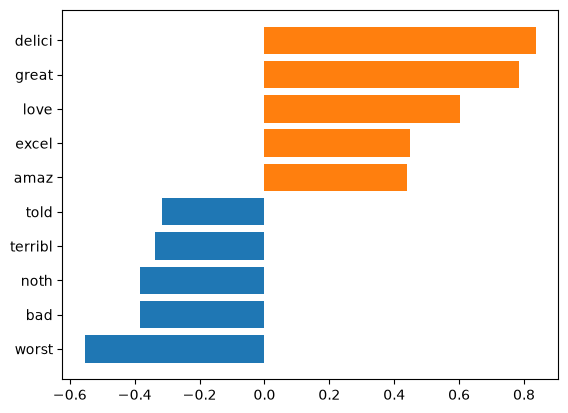

In [29]:
## get top features
las_coef = pd.DataFrame({'coef': logit_lasso.coef_[0],
                         'feature_name': X_train.columns})

top_feat = las_coef.sort_values(by = 'coef', ascending = True)[-5:]
bot_feat = las_coef.sort_values(by = 'coef', ascending = True)[0:5]
plt.barh(bot_feat.feature_name, bot_feat.coef)
plt.barh(top_feat.feature_name, top_feat.coef)

# 3. Compare performance across hyperparameters for logistic regression

Would our logit model make more accurate predictions if we fed it different hyperpameters? Which hyperparameters would be the best? Let's find out.

1. Define a function that:
- takes in a cost parameter (*C*, the inverse of regularization strength)
- trains a logistic regression model with L1 regularization (Lasso) and otherwise has the same parameters as above
- fits the model on the training data
- makes predictions and returns them as a DataFrame

2. Use the function to get predictions for the list of *C* parameters below, then bind them into one DataFrame.

3. Finally, score the precision for each model (each iteration of *C*) and show which model scores the best.

**Hint**: To compute precision score, you can use:
```python
precision_score(
    one_df['y_true'], one_df['y_pred'],
    zero_division = 0) # silences warning
```

In [58]:
# Provided set of hyperparameters on which to train and then compare performance
c_list = np.linspace(4, 0.0001, 5)

In [59]:
# your function code here

def logit_model(cost):
    logit_lasso = LogisticRegression(penalty = "l1",max_iter=100, 
             C = cost, solver='liblinear')
    logit_lasso.fit(X_train, y_train)
    y_pred = logit_lasso.predict(X_test)

    y_predprob = logit_lasso.predict_proba(X_test)

    y_pred_df = pd.DataFrame({'y_pred_binary': y_pred,
                         'y_pred_continuous': [one_prob[1] 
                                            for one_prob in y_predprob],
                         'y_true': y_test.metadata_label.values})
    return y_pred_df
    

In [60]:
# your code here to evaluate precision of each model
for c in c_list:

    one_df = logit_model(c)
    precision = precision_score(
    one_df['y_true'], one_df['y_pred_binary'],
    zero_division = 0)

    print("Precision for " + str(c) + " is " + str(precision))

/Users/isaacsaxonov/miniconda3/envs/qsst/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/isaacsaxonov/miniconda3/envs/qsst/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/isaacsaxonov/miniconda3/envs/qsst/lib/python3.12/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y

Precision for 4.0 is 0.8617021276595744


/Users/isaacsaxonov/miniconda3/envs/qsst/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/isaacsaxonov/miniconda3/envs/qsst/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/isaacsaxonov/miniconda3/envs/qsst/lib/python3.12/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y

Precision for 3.000025 is 0.8684913217623498


/Users/isaacsaxonov/miniconda3/envs/qsst/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/isaacsaxonov/miniconda3/envs/qsst/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/isaacsaxonov/miniconda3/envs/qsst/lib/python3.12/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y

Precision for 2.00005 is 0.8745785569790965


/Users/isaacsaxonov/miniconda3/envs/qsst/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/isaacsaxonov/miniconda3/envs/qsst/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/isaacsaxonov/miniconda3/envs/qsst/lib/python3.12/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y

Precision for 1.0000750000000003 is 0.8752515090543259


/Users/isaacsaxonov/miniconda3/envs/qsst/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/isaacsaxonov/miniconda3/envs/qsst/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/isaacsaxonov/miniconda3/envs/qsst/lib/python3.12/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y

Precision for 0.0001 is 0.0


# 4. Activity 

- Read the documentation here to initialize a ridge regression (l2 penalty)- you can use the same cost parameter (C) and number of iterations as in the lasso example above: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
- Fit the model on X_train_man, y_train_main 
- Generate binary and continuous predictions
- Create a function that takes in a dataframe of binary predictions and true labels and manually calculates the $F_{1}$ score:

$$F_{1} = 2 * \dfrac{precision * recall}{precision + recall} = \dfrac{TP}{TP + 0.5(FP + FN)}$$

- Apply that function to calculate the F1 score for the decision tree and lasso (from above), and ridge regression (from the activity)
- *Challenge exercise*: parametrize the model fitting with a function that takes in a classifier as an argument and returns coefficients or feature importances and certain eval metrics (eg precision, recall, and F1)

In [54]:
# your code here 

# your function code here

def logit_model_ridge(cost):
    logit_ridge = LogisticRegression(penalty = "l2",max_iter=100, 
             C = cost, solver='liblinear')
    logit_ridge.fit(X_train, y_train)
    y_pred = logit_ridge.predict(X_test)

    y_predprob = logit_ridge.predict_proba(X_test)

    y_pred_df = pd.DataFrame({'y_pred_binary': y_pred,
                         'y_pred_continuous': [one_prob[1] 
                                            for one_prob in y_predprob],
                         'y_true': y_test.metadata_label.values})
    return y_pred_df
    

In [62]:
# your code here to evaluate precision of each model
c=c_list[2]

one_df_ridge = logit_model_ridge(c)
precision = precision_score(
one_df_ridge['y_true'], one_df_ridge['y_pred_binary'],
zero_division = 0)

print("Precision for " + str(c) + " is " + str(precision))

c=c_list[2]

one_df = logit_model(c)
precision = precision_score(
one_df['y_true'], one_df['y_pred_binary'],
zero_division = 0)

print("Precision for " + str(c) + " is " + str(precision))

/Users/isaacsaxonov/miniconda3/envs/qsst/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/isaacsaxonov/miniconda3/envs/qsst/lib/python3.12/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Precision for 2.00005 is 0.8725556304787593


/Users/isaacsaxonov/miniconda3/envs/qsst/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/isaacsaxonov/miniconda3/envs/qsst/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/isaacsaxonov/miniconda3/envs/qsst/lib/python3.12/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y

Precision for 2.00005 is 0.8745785569790965


In [56]:
def f1_score(df):
    precision = precision_score(
        df['y_true'], df['y_pred_binary'],
        zero_division = 0)
    recall = recall_score(
        df['y_true'], df['y_pred_binary'],
        zero_division = 0)
    
    return 2 * (precision * recall)/(precision + recall)

    

In [57]:
print(f1_score(one_df_ridge))

0.8772881355932203


In [63]:
print(f1_score(one_df))

0.8793220338983052


In [70]:
def get_results(model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_predprob = model.predict_proba(X_test)
    y_pred_df = pd.DataFrame({'y_pred_binary': y_pred,
                              'y_pred_continuous': [one_prob[1]
                                                    for one_prob in y_predprob],
                              'y_true': y_test.metadata_label.values})
    return [f1_score(y_pred_df),
            precision_score(y_pred_df['y_true'], y_pred_df['y_pred_binary'], zero_division=0),
            recall_score(y_pred_df['y_true'], y_pred_df['y_pred_binary'], zero_division=0)]

In [71]:
print(get_results(LogisticRegression(penalty = "l2",max_iter=100, 
             C=1.5, solver='liblinear')))

/Users/isaacsaxonov/miniconda3/envs/qsst/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/isaacsaxonov/miniconda3/envs/qsst/lib/python3.12/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[0.8780984719864177, 0.874830852503383, 0.8813905930470347]
